In [15]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

In [16]:
FEATURE_PATH = "/home/chupchik/Рабочий стол/fisrt_stepD/The_final_recomendation/output_dataset/wazuh_features.parquet"

df = pd.read_parquet(FEATURE_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (2493428, 31)


,scenario,timestamp,agent_id,agent_name,agent_ip,hostname,program,location,full_log,rule_id,...,has_401,has_403,has_500,has_sql,has_admin,has_wp,grp_attack,grp_recon,grp_scan,grp_auth
0,fox,2022-01-15 02:32:32+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:32 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0
1,fox,2022-01-15 02:32:32+00:00,6,wazuh-client,192.168.128.170,taylorcruz-mail,freshclam,/var/log/syslog,Jan 15 02:32:32 taylorcruz-mail freshclam[2851...,52507,...,0,0,0,0,0,0,0,0,0,0
2,fox,2022-01-15 02:32:37+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:37 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0
3,fox,2022-01-15 02:32:42+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:42 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0
4,fox,2022-01-15 02:32:47+00:00,18,wazuh-client,172.17.131.81,mail,freshclam,/var/log/syslog,Jan 15 02:32:47 mail freshclam[29266]: Sat Jan...,52507,...,0,0,0,0,0,0,0,0,0,0


In [17]:
binary_cols = [
    "has_400", "has_401", "has_403", "has_500",
    "has_sql", "has_admin", "has_wp",
    "grp_attack", "grp_recon", "grp_scan", "grp_auth"
]

for col in binary_cols:
    if col in df.columns:
        print(f"{col}:")
        print(df[col].value_counts())
        print("-" * 40)

has_400:
has_400
0    2493428
Name: count, dtype: int64
----------------------------------------
has_401:
has_401
0    2493426
1          2
Name: count, dtype: int64
----------------------------------------
has_403:
has_403
0    2490758
1       2670
Name: count, dtype: int64
----------------------------------------
has_500:
has_500
0    2493361
1         67
Name: count, dtype: int64
----------------------------------------
has_sql:
has_sql
0    2491231
1       2197
Name: count, dtype: int64
----------------------------------------
has_admin:
has_admin
0    2265012
1     228416
Name: count, dtype: int64
----------------------------------------
has_wp:
has_wp
1    1625863
0     867565
Name: count, dtype: int64
----------------------------------------
grp_attack:
grp_attack
1    1574317
0     919111
Name: count, dtype: int64
----------------------------------------
grp_recon:
grp_recon
0    2371590
1     121838
Name: count, dtype: int64
----------------------------------------
grp_scan:
g

In [18]:
df[df["full_log"].str.contains("400", na=False)].head(5)

,scenario,timestamp,agent_id,agent_name,agent_ip,hostname,program,location,full_log,rule_id,...,has_401,has_403,has_500,has_sql,has_admin,has_wp,grp_attack,grp_recon,grp_scan,grp_auth
84,fox,2022-01-15 06:13:01+00:00,20,wazuh-client,172.17.130.37,wazuh-client,auditd,/var/log/audit/audit.log,type=AVC msg=audit(1642227181.529:500): apparm...,80730,...,0,0,0,0,0,0,0,0,0,0
85,fox,2022-01-15 06:13:01+00:00,20,wazuh-client,172.17.130.37,wazuh-client,auditd,/var/log/audit/audit.log,type=AVC msg=audit(1642227181.529:499): apparm...,80730,...,0,0,0,0,0,0,0,0,0,0
86,fox,2022-01-15 06:13:01+00:00,20,wazuh-client,172.17.130.37,wazuh-client,auditd,/var/log/audit/audit.log,type=AVC msg=audit(1642227181.533:501): apparm...,80730,...,0,0,0,0,0,0,0,0,0,0
87,fox,2022-01-15 06:13:01+00:00,20,wazuh-client,172.17.130.37,wazuh-client,auditd,/var/log/audit/audit.log,type=AVC msg=audit(1642227181.533:502): apparm...,80730,...,0,0,0,0,0,0,0,0,0,0
134,fox,2022-01-15 06:24:58+00:00,27,wazuh-client,10.35.35.206,wazuh-client,auditd,/var/log/audit/audit.log,type=AVC msg=audit(1642227898.609:519): apparm...,80730,...,0,0,0,0,0,0,0,0,0,0


In [19]:
print("Количество столбцов:", len(df.columns))
print(df.columns.tolist())

Количество столбцов: 31
['scenario', 'timestamp', 'agent_id', 'agent_name', 'agent_ip', 'hostname', 'program', 'location', 'full_log', 'rule_id', 'rule_level', 'rule_description', 'rule_groups', 'rule_groups_str', 'y_priority', 'hour', 'dayofweek', 'is_weekend', 'is_night', 'is_internal_ip', 'has_400', 'has_401', 'has_403', 'has_500', 'has_sql', 'has_admin', 'has_wp', 'grp_attack', 'grp_recon', 'grp_scan', 'grp_auth']


In [20]:
if "y_priority" not in df.columns:
    raise ValueError("В датасете нет столбца 'y_priority'. Проверь название таргета.")

print(df["y_priority"].value_counts(dropna=False))
print()
print(df["y_priority"].value_counts(normalize=True, dropna=False))


y_priority
medium      1873575
low          486285
high         131901
critical       1667
Name: count, dtype: int64

y_priority
medium      0.751405
low         0.195027
high        0.052899
critical    0.000669
Name: proportion, dtype: float64


In [21]:
df = df.dropna(subset=["y_priority"]).copy()

print("Shape after dropna target:", df.shape)

Shape after dropna target: (2493428, 31)


In [22]:
leakage_cols = [
    "rule_id",
    "rule_level",
    "severity",
    "rule_description",
    "rule_groups"
]

existing_leakage_cols = [col for col in leakage_cols if col in df.columns]
print("Leakage columns found:", existing_leakage_cols)

Leakage columns found: ['rule_id', 'rule_level', 'rule_description', 'rule_groups']


In [23]:
target_col = "y_priority"

text_candidates = [
    "full_log"
]

numeric_candidates = [
    "hour",
    "dayofweek",
    "is_weekend",
    "is_night",
    "is_internal_ip",
    "has_400",
    "has_401",
    "has_403",
    "has_500",
    "has_sql",
    "has_admin",
    "has_wp"
]

categorical_candidates = [
    "program",
    "location",
    "scenario"
]

text_features = [col for col in text_candidates if col in df.columns]
numeric_features = [col for col in numeric_candidates if col in df.columns]
categorical_features = [col for col in categorical_candidates if col in df.columns]

print("Text features:", text_features)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Text features: ['full_log']
Numeric features: ['hour', 'dayofweek', 'is_weekend', 'is_night', 'is_internal_ip', 'has_400', 'has_401', 'has_403', 'has_500', 'has_sql', 'has_admin', 'has_wp']
Categorical features: ['program', 'location', 'scenario']


In [24]:
used_features = text_features + numeric_features + categorical_features

X = df[used_features].copy()
y = df[target_col].copy()

# Для текста заполняем пропуски заранее
for col in text_features:
    X[col] = X[col].fillna("").astype(str)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2493428, 16)
y shape: (2493428,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1994742, 16) (1994742,)
Test : (498686, 16) (498686,)


In [26]:
transformers = []

if len(text_features) > 0:
    text_transformer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.95,
        sublinear_tf=True,
        max_features=50000
    )
    transformers.append(("text", text_transformer, text_features[0]))

if len(numeric_features) > 0:
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("scaler", StandardScaler(with_mean=False))
    ])
    transformers.append(("num", numeric_transformer, numeric_features))

if len(categorical_features) > 0:
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    transformers.append(("cat", categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

In [27]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

svm_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [28]:
svm_pipeline.fit(X_train, y_train)
print("LinearSVC training finished.")

LinearSVC training finished.


In [29]:
y_pred = svm_pipeline.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Macro F1   : {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

Macro F1   : 0.4958
Weighted F1: 0.9187


In [30]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

    critical     0.0092    0.0539    0.0157       334
        high     0.1255    0.0025    0.0049     26380
         low     1.0000    1.0000    1.0000     97257
      medium     0.9335    0.9938    0.9627    374715

    accuracy                         0.9420    498686
   macro avg     0.5170    0.5125    0.4958    498686
weighted avg     0.9031    0.9420    0.9187    498686



In [31]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"true_{c}" for c in sorted(y.unique())],
    columns=[f"pred_{c}" for c in sorted(y.unique())]
)

display(cm_df)

,pred_critical,pred_high,pred_low,pred_medium
true_critical,18,1,0,315
true_high,97,66,0,26217
true_low,0,4,97253,0
true_medium,1851,455,1,372408


In [32]:
results_df = pd.DataFrame([
    {
        "model": "LinearSVC_clean_baseline",
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "text_features": ", ".join(text_features),
        "numeric_count": len(numeric_features),
        "categorical_count": len(categorical_features)
    }
])

display(results_df)

,model,macro_f1,weighted_f1,text_features,numeric_count,categorical_count
0,LinearSVC_clean_baseline,0.495814,0.918687,full_log,12,3


In [33]:
results_path = "/home/chupchik/Рабочий стол/fisrt_stepD/The_final_recomendation/output_dataset/linear_svm_results.csv"
results_df.to_csv(results_path, index=False)

print("Saved to:", results_path)

Saved to: /home/chupchik/Рабочий стол/fisrt_stepD/The_final_recomendation/output_dataset/linear_svm_results.csv


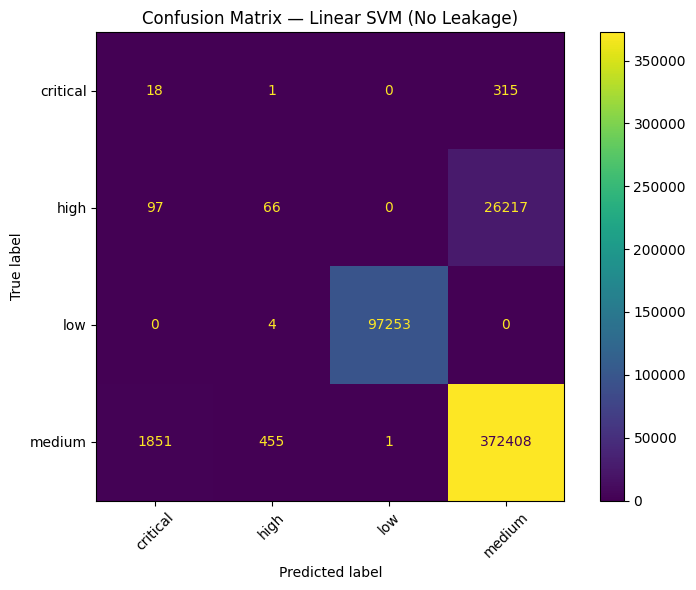

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# считаем матрицу
cm = confusion_matrix(y_test, y_pred)

# подписи классов (важно сохранить порядок)
labels = sorted(y.unique())

# строим график
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix — Linear SVM (No Leakage)")
plt.tight_layout()
plt.show()

In [1]:
print(numeric_features)

NameError: name 'numeric_features' is not defined